# Import Labraries

In [1]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sbn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

# Load Files

In [2]:
train_data = pd.read_csv("../input/digit-recognizer/train.csv")
test_data = pd.read_csv("../input/digit-recognizer/test.csv")
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#shape
print(f'training data shape: {train_data.shape}\ntesting data shape: {test_data.shape}')

training data shape: (42000, 785)
testing data shape: (28000, 784)


In [4]:
#Train Test Split
train_set, val_set = train_test_split(train_data, test_size=0.01, random_state=10)
train_set.shape, val_set.shape

((41580, 785), (420, 785))

# Visualize a sample

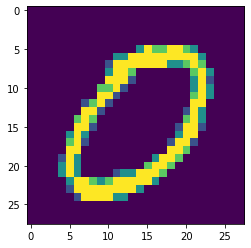

In [5]:
plt.imshow(train_set.iloc[0, 1:].to_numpy().reshape(28, 28))
plt.show()

# Create the DataLoader

In [6]:
class mnistDataset(Dataset):
    def __init__(self, df):
        self.df = df
        x = self.df.iloc[:,1:]
        y = self.df.label
        self.x = torch.tensor(np.array(x).reshape(-1, 1, 28, 28), dtype=torch.float)
        self.y = torch.tensor(np.array(y), dtype=torch.float)
        
    def __getitem__(self, index):
        return self.x[index], self.y[index]
    
    def __len__(self):
        return self.df.shape[0]

In [7]:
train_mnistDataset = mnistDataset(train_set)
val_mnistDataset = mnistDataset(val_set)

In [8]:
BATCH_SIZE = 50
train_data_loader = DataLoader(dataset=train_mnistDataset, batch_size=BATCH_SIZE, shuffle=True)
val_data_loader = DataLoader(dataset=val_mnistDataset, batch_size=BATCH_SIZE, shuffle=True)

In [9]:
#shape of the data in train_data_loader
for data, label in train_data_loader:
    print(data.shape)
    print(label.shape)
    break

torch.Size([50, 1, 28, 28])
torch.Size([50])


# Build CNN Architecture

In [10]:
class CNNModel(nn.Module):
    def __init__(self, in_, out_):
        super(CNNModel, self).__init__()
        
        self.conv_pool_01 = nn.Sequential(
        nn.Conv2d(in_channels = in_, out_channels=128, kernel_size=3, stride=1, padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride = 1)
        )
        
        self.conv_pool_02 = nn.Sequential(
        nn.Conv2d(in_channels = 128, out_channels=256, kernel_size=3, stride=1, padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride = 1)
        )
        
        self.conv_pool_03 = nn.Sequential(
        nn.Conv2d(in_channels = 256, out_channels=512, kernel_size=3, stride=1, padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride = 1)
        )
        
        self.flatten = nn.Flatten()
        self.fc_01 = nn.Linear(in_features = 512*19*19, out_features=512)
        self.fc_02 = nn.Linear(in_features = 512, out_features=256)
        self.fc_03 = nn.Linear(in_features = 256, out_features=out_)
        
        
    def forward(self, x):
        x = self.conv_pool_01(x)
        x = self.conv_pool_02(x)
        x = self.conv_pool_03(x)
        x = self.flatten(x)
        x = self.fc_01(x)
        x = self.fc_02(x)
        x = self.fc_03(x)
        return x

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [12]:
model = CNNModel(1, 10)
model.to(device)

CNNModel(
  (conv_pool_01): Sequential(
    (0): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_pool_02): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_pool_03): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc_01): Linear(in_features=184832, out_features=512, bias=True)
  (fc_02): Linear(in_features=512, out_features=256, bias=True)
  (fc_03): Linear(in_features=256, out_features=10, bias=True)
)

# Count No. of Trainable Parameters

In [13]:
def count_params(model):
    model_params = {'Modules': list(), 'Parameters':list()}
    total = 0
    for name, parameters in model.named_parameters():
        if not parameters.requires_grad:
            continue
        param = parameters.numel()
        model_params['Modules'].append(name)
        model_params['Parameters'].append(param)
        total += param
    df = pd.DataFrame(model_params)
    return df, total

df, total = count_params(model)
print("Total parameters", total)
df

Total parameters 96245002


,Modules,Parameters
0,conv_pool_01.0.weight,1152
1,conv_pool_01.0.bias,128
2,conv_pool_02.0.weight,294912
3,conv_pool_02.0.bias,256
4,conv_pool_03.0.weight,1179648
5,conv_pool_03.0.bias,512
6,fc_01.weight,94633984
7,fc_01.bias,512
8,fc_02.weight,131072
9,fc_02.bias,256


# Train the Model

In [14]:
learning_rate = 0.00001
EPOCHS= 15
#Loss and Optimizer
Criterion_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

In [15]:
for epoch in range(EPOCHS):
    with tqdm(train_data_loader) as tqdm_epoch:
        for images, labels in tqdm_epoch:
            tqdm_epoch.set_description(f"Epoch {epoch + 1} / {EPOCHS}")
            images = images.to(device)
            labels = labels.type(torch.LongTensor).to(device)
        
            #Forward Propagation
            pred = model(images)
            loss = Criterion_loss(pred, labels)

            #Backward Propagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            accuracy = torch.mean((torch.argmax(pred, 1)==labels).float()).item()
            tqdm_epoch.set_postfix(loss = loss.item(), accuracy = accuracy)

Epoch 15 / 15: 100%|██████████| 832/832 [00:39<00:00, 21.19it/s, accuracy=1, loss=0.000164]


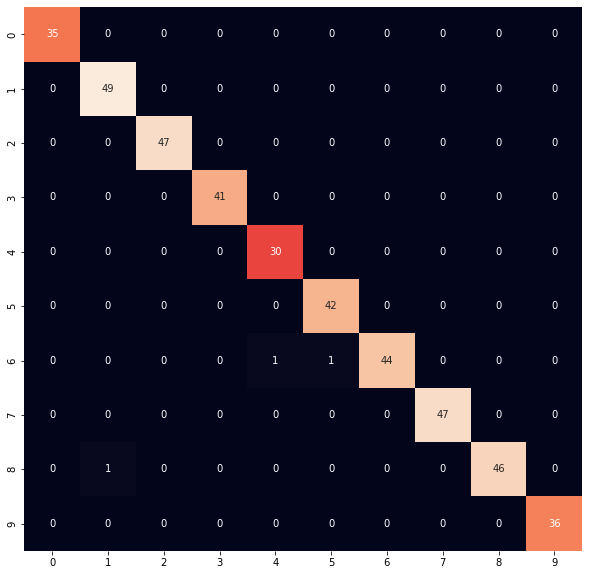

In [16]:
pred = np.array([])
target = np.array([])

with torch.no_grad():
    for batch, data in enumerate(val_data_loader):
        image, label = data[0].to(device), data[1].to(device)
        
        y_pred = model(image)
        
        pred = np.concatenate((pred, torch.argmax(y_pred, 1).cpu().numpy()))
        target = np.concatenate((target, label.cpu().numpy()))
cm = confusion_matrix(target, pred)
plt.figure(figsize=(10, 10))
sbn.heatmap(cm, annot=True, fmt = 'd', cbar=False)
plt.show()

# Submission to Kaggle

In [17]:
class testmnistDataset(Dataset):
    def __init__(self, df):
        self.df = df
        x = self.df.iloc[:,0:]
        self.x = torch.tensor(np.array(x).reshape(-1, 1, 28, 28), dtype=torch.float)
        
    def __getitem__(self, index):
        return self.x[index]
    
    def __len__(self):
        return self.df.shape[0]

In [18]:
test_mnistDataset = testmnistDataset(test_data)
test_data_loader = DataLoader(dataset=test_mnistDataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
pred = np.array([])
with torch.no_grad():
    for batch, data in enumerate(test_data_loader):
        image = data.to(device)
        y_pred = model(image)
        pred = np.concatenate((pred, torch.argmax(y_pred, 1).cpu().numpy()))
ImageId = []
for i in range(len(pred)):
    ImageId.append(i+1)

In [20]:
test_data['ImageId']=ImageId
test_data['Label']=pred.astype('int')
test_data[['ImageId', 'Label']].to_csv("Submission.csv", index=False)